#  Pokédex DSP + Machine Learning
## Hệ thống nhận diện Pokémon sử dụng Xử lý Tín hiệu Số & SVM




## 1.  Import thư viện

Các thư viện chính:
- **OpenCV** (`cv2`): Xử lý ảnh, lọc nhiễu, phát hiện cạnh
- **NumPy**: Tính toán ma trận và FFT
- **scikit-image**: Trích xuất HOG features
- **scikit-learn**: SVM, GridSearchCV, StandardScaler
- **matplotlib / seaborn**: Trực quan hóa


In [15]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler

# Cấu hình hiển thị
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Đường dẫn
DATA_DIR  = "data"
MODEL_DIR = "Model"

print(" Import thành công!")
print(f"   OpenCV:       {cv2.__version__}")
print(f"   NumPy:        {np.__version__}")


 Import thành công!
   OpenCV:       4.13.0
   NumPy:        2.4.3


## 2.  Kiến trúc dự án

```
Pokédex DSP + ML Pipeline
══════════════════════════════════════════════════════

  INPUT IMAGE
       │
       ▼
  ┌─────────────────────┐
  │  1. PREPROCESSING   │  Median Blur → Bilateral Filter
  │     (DSP Denoise)   │  Giảm nhiễu giữ cạnh
  └─────────┬───────────┘
            │
            ▼
  ┌─────────────────────┐
  │  2. EDGE DETECTION  │  Auto Canny → Morphology Close
  │     (DSP Edges)     │  Phát hiện biên thích ứng
  └─────────┬───────────┘
            │
            ▼
  ┌─────────────────────┐
  │  3. FEATURE         │  Fourier Descriptors (32-dim)
  │     EXTRACTION      │  HOG Features (N-dim)
  │                     │  HSV Histogram (1024-dim)
  └─────────┬───────────┘
            │
            ▼
  ┌─────────────────────┐
  │  4. AUGMENTATION    │  11 biến thể / ảnh gốc
  │     + DATASET       │  (Flip, Rotate, Scale, Noise...)
  └─────────┬───────────┘
            │
            ▼
  ┌─────────────────────┐
  │  5. TRAINING        │  StandardScaler → GridSearchCV
  │     (SVM + RBF)     │  SVM(kernel=rbf, C, gamma)
  └─────────┬───────────┘
            │
            ▼
  ┌─────────────────────┐
  │  6. PREDICTION      │  Load model → Extract → Predict
  │     + EVALUATION    │  Accuracy / F1 / Confusion Matrix
  └─────────────────────┘
```

### Các module chính:

| Module | Chức năng |
|--------|-----------|
| `preprocess.py` | Khử nhiễu DSP (Median + Bilateral), phát hiện cạnh (Canny + Morphology) |
| `features.py` | Trích xuất Fourier Descriptors, HOG, HSV Histogram |
| `dataset.py` | Data Augmentation (11 biến thể), load & xử lý dataset |
| `model.py` | Định nghĩa SVM base model |
| `train.py` | Train pipeline: Split → Scale → GridSearch → Evaluate |
| `predict.py` | Inference: Load model → Predict → Giải thích |


## 3.  Tiền xử lý ảnh DSP (Digital Signal Processing)

### 3.1 Tổng quan Pipeline khử nhiễu

Ảnh Pokémon thu thập từ nhiều nguồn thường chứa **nhiễu** (noise) làm ảnh hưởng đến feature extraction.
Pipeline DSP gồm 4 bước:

1. **Median Blur** — Khử nhiễu muối tiêu (salt-and-pepper noise)
2. **Bilateral Filter** — Làm mịn giữ cạnh (edge-preserving smoothing)
3. **Auto Canny** — Phát hiện biên thích ứng
4. **Morphology Close** — Nối liền các đường biên đứt

### 3.2 Median Blur

Median filter thay thế mỗi pixel bằng **giá trị trung vị** (median) của vùng lân cận $k \times k$:

$$g(x,y) = \text{median}\{f(x+i, y+j) \mid (i,j) \in W_{k \times k}\}$$

- **Ưu điểm:** Loại bỏ nhiễu xung (impulse noise) hiệu quả mà **không làm mờ cạnh** như Gaussian blur
- **Kernel size = 3:** Cân bằng giữa khử nhiễu và bảo toàn chi tiết

### 3.3 Bilateral Filter

Bilateral filter kết hợp **domain filter** (không gian) và **range filter** (cường độ):

$$BF[I]_p = \frac{1}{W_p} \sum_{q \in S} G_{\sigma_s}(\|p - q\|) \cdot G_{\sigma_r}(\|I_p - I_q\|) \cdot I_q$$

Trong đó:
- $G_{\sigma_s}$: Gaussian kernel không gian (spatial) — `sigmaSpace = 75`
- $G_{\sigma_r}$: Gaussian kernel cường độ (range) — `sigmaColor = 75`
- $d = 9$: Đường kính vùng lân cận

> **Key insight:** Bilateral filter chỉ lấy trung bình các pixel có cường độ **tương tự** → **giữ nguyên biên cạnh** trong khi làm mịn vùng phẳng.

### 3.4 Auto Canny Edge Detection

Thuật toán Canny với ngưỡng **tự động** dựa trên median:

$$\text{lower} = \max(0,\; (1 - \sigma) \cdot \tilde{I})$$
$$\text{upper} = \min(255,\; (1 + \sigma) \cdot \tilde{I})$$

với $\tilde{I}$ là median intensity, $\sigma = 0.33$.

### 3.5 Morphology Close

Phép đóng hình thái học = **Dilation** + **Erosion**:

$$\text{Close}(A, B) = (A \oplus B) \ominus B$$

Kernel $2 \times 2$ MORPH_RECT giúp nối liền các đường biên nhỏ bị đứt.


### 3.6 Triển khai DSP Functions

In [16]:
# ===== DSP PREPROCESSING FUNCTIONS =====

def bilateral_denoise(img):
    """Khử nhiễu 2 bước: Median Blur → Bilateral Filter"""
    img = cv2.medianBlur(img, 3)
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)


def auto_canny(gray, sigma=0.33):
    """Canny edge detection với ngưỡng tự động"""
    median = np.median(gray)
    lower  = int(max(0,   (1.0 - sigma) * median))
    upper  = int(min(255, (1.0 + sigma) * median))
    return cv2.Canny(gray, lower, upper)


def clean_edges(edges):
    """Morphology Close để nối liền biên đứt"""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    return cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)


def extract_pokemon(image_path):
    """Pipeline tiền xử lý hoàn chỉnh cho model"""
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.resize(img, (128, 128))
    img = bilateral_denoise(img)
    return cv2.resize(img, (64, 64))


def extract_pokemon_debug(image_path):
    """Pipeline tiền xử lý với output từng bước (dùng cho visualization)"""
    img = cv2.imread(image_path)
    if img is None:
        return None
    original = cv2.resize(img, (128, 128))
    denoised = bilateral_denoise(original)
    gray      = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)
    edges     = auto_canny(gray)
    edges     = clean_edges(edges)
    edges_col = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    return {
        "original": original,
        "blur":     denoised,
        "edges":    edges_col,
        "combine":  denoised,
        "final":    cv2.resize(denoised, (64, 64))
    }

print(" DSP functions đã sẵn sàng")


 DSP functions đã sẵn sàng


## 4.  Visualization Pipeline

Hiển thị toàn bộ quá trình xử lý ảnh qua từng bước DSP:
**Original → Denoised → Edge Detection → Final Output**


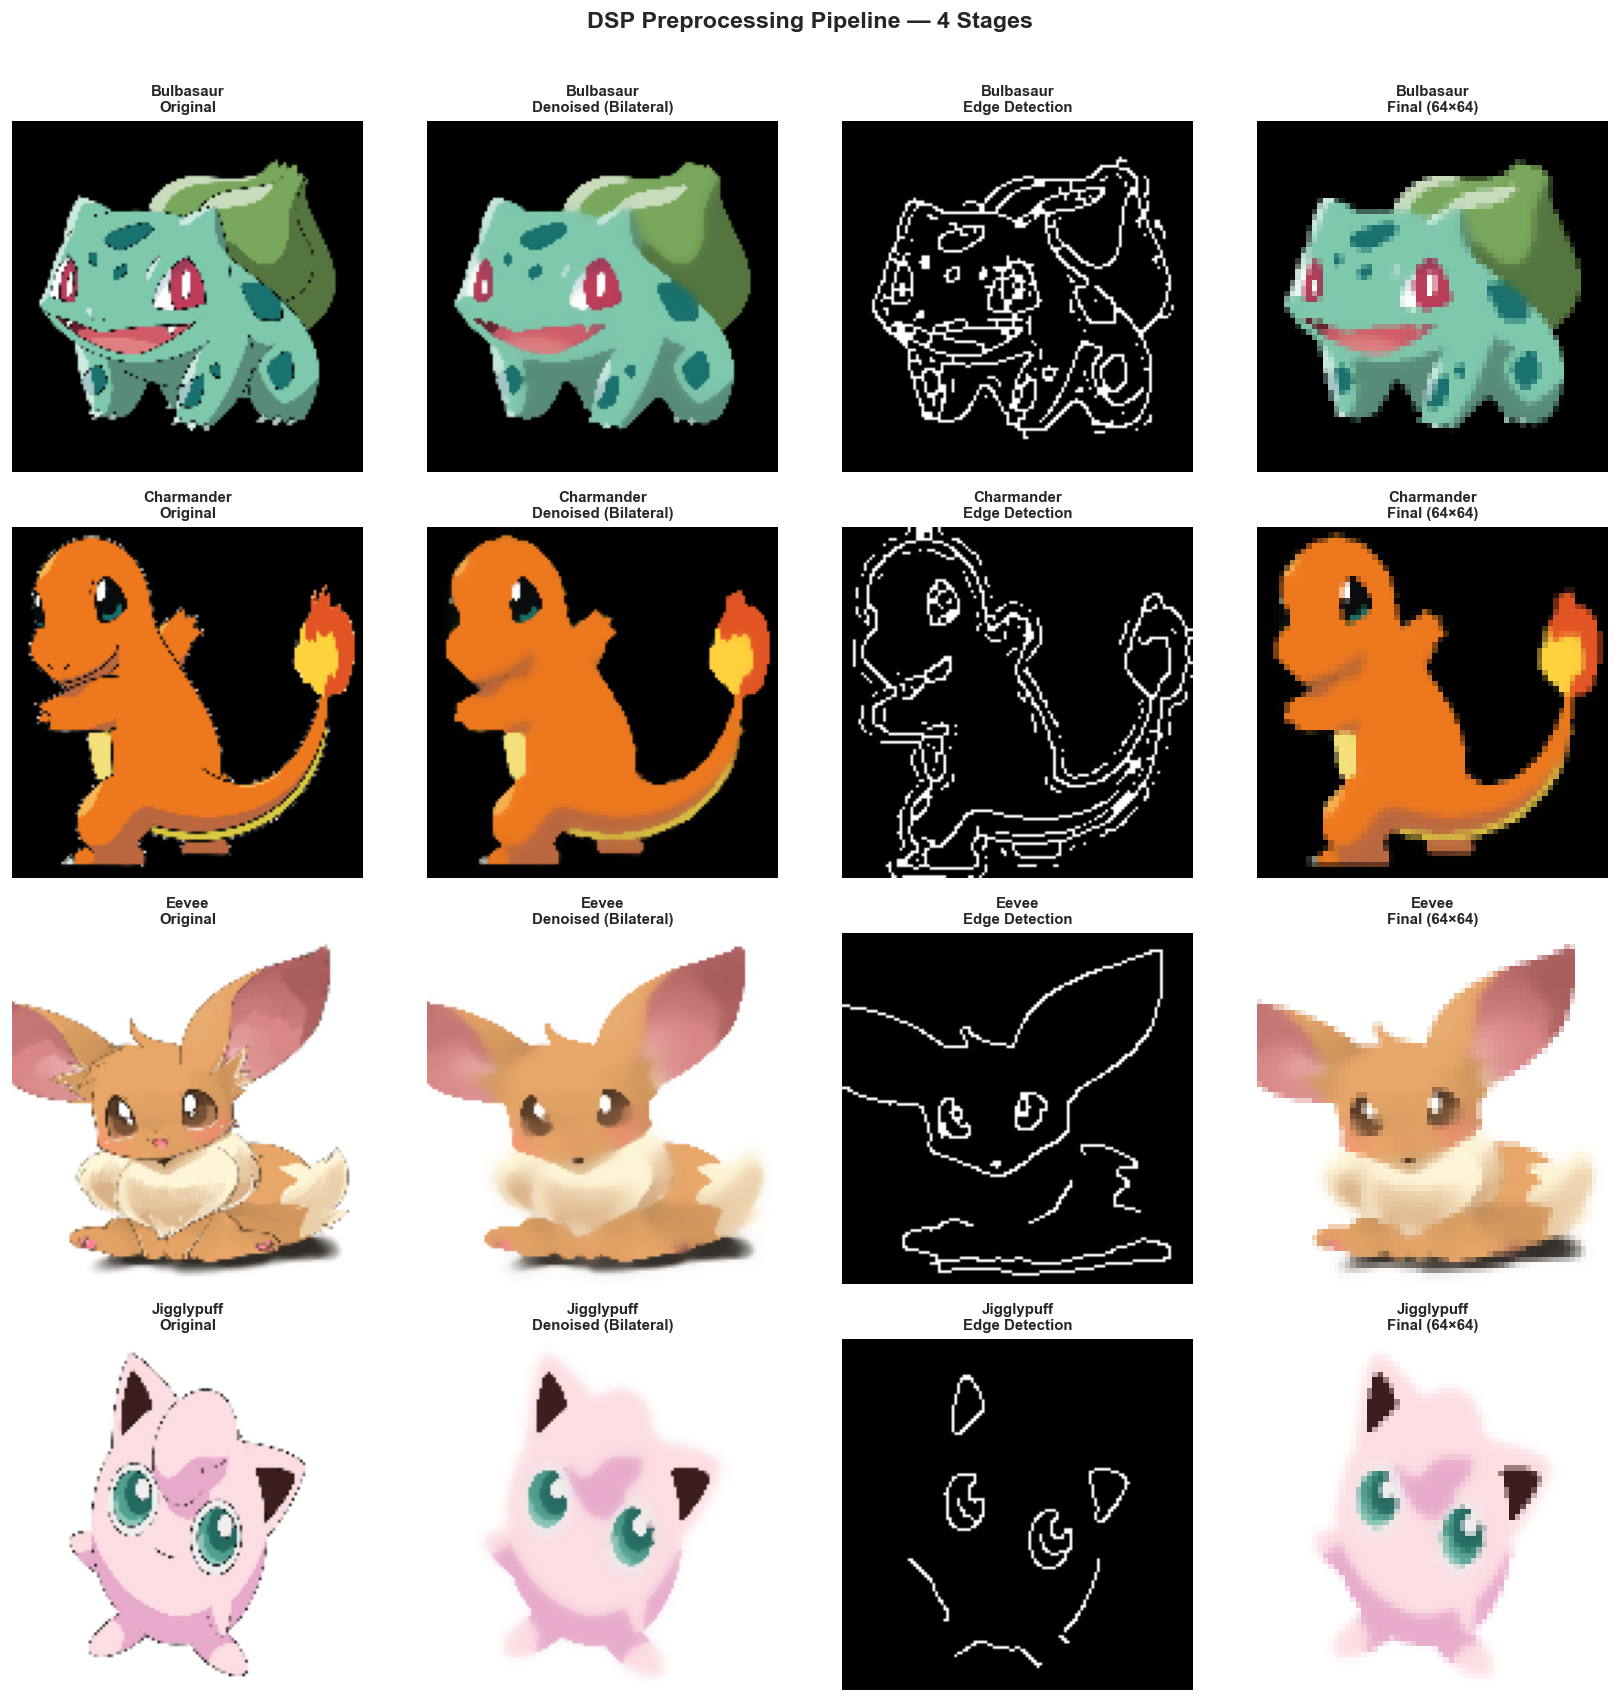

In [17]:
# ===== TÌM ẢNH MẪU =====
sample_images = []
for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        if files:
            sample_images.append((class_name, os.path.join(class_path, files[0])))

# Lấy 4 Pokémon đầu tiên
samples = sample_images[:4]

fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3.5 * len(samples)))

for i, (name, path) in enumerate(samples):
    result = extract_pokemon_debug(path)
    if result is None:
        continue

    titles = ["Original", "Denoised (Bilateral)", "Edge Detection", "Final (64×64)"]
    images = [result["original"], result["blur"], result["edges"], result["final"]]

    for j, (title, img) in enumerate(zip(titles, images)):
        ax = axes[i, j] if len(samples) > 1 else axes[j]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name.capitalize()}\n{title}", fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle("DSP Preprocessing Pipeline — 4 Stages", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5.  Fourier Descriptors — DSP Shape Analysis

### 5.1 Lý thuyết Biến đổi Fourier

**Biến đổi Fourier rời rạc (DFT)** chuyển tín hiệu từ miền **thời gian/không gian** sang miền **tần số**:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}, \quad k = 0, 1, \ldots, N-1$$

Trong đó:
- $x[n]$: Tín hiệu đầu vào (tọa độ contour phức: $z[n] = x[n] + j \cdot y[n]$)
- $X[k]$: Hệ số Fourier tại tần số $k$
- $N$: Số điểm trên contour (resample = 128 điểm)

### 5.2 Ý nghĩa DSP của Fourier Descriptors

| Tần số | Ý nghĩa hình học |
|--------|-------------------|
| $X[0]$ | Vị trí trung tâm (centroid) — **bỏ qua** |
| $X[1]$ | Bán kính trung bình — dùng để **chuẩn hóa** (scale invariant) |
| $X[2..8]$ | **Hình dạng tổng thể** (tròn, dài, méo...) |
| $X[9..32]$ | **Chi tiết nhỏ** (tai, đuôi, chân...) |
| $X[33..]$ | Nhiễu cao tần — **cắt bỏ** (low-pass filtering) |

> **Key insight:** Giữ lại $k = 1..32$ hệ số tương đương **bộ lọc thông thấp** (low-pass filter) trên hình dạng contour, loại bỏ nhiễu chi tiết nhưng giữ đặc trưng hình dáng.

### 5.3 Pipeline Fourier

1. Grayscale → Median + Gaussian blur
2. Auto Canny → Morphology Close → **findContours**
3. Lọc contour theo diện tích (> 20% contour lớn nhất)
4. Resample 128 điểm đều → $z[n] = x[n] + jy[n]$
5. **FFT** → Magnitude spectrum → Chuẩn hóa scale invariant
6. Weighted average theo diện tích → **32 Fourier Descriptors**


In [18]:
# ===== FOURIER DESCRIPTORS =====

def get_fourier_descriptors(img, num_descriptors=32):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 3)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    edges = auto_canny(blur)
    edges = clean_edges(edges)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if len(contours) == 0:
        return np.zeros(num_descriptors)

    areas = [cv2.contourArea(c) for c in contours]
    max_area = max(areas)
    valid_contours = [c for c, a in zip(contours, areas) if a > 0.2 * max_area]

    fd_all  = []
    weights = []

    for contour in valid_contours:
        area    = cv2.contourArea(contour)
        contour = contour.squeeze()

        if len(contour.shape) != 2 or len(contour) < 32:
            continue

        idx     = np.linspace(0, len(contour) - 1, 128).astype(int)
        contour = contour[idx]

        contour_complex = contour[:, 0] + 1j * contour[:, 1]
        fourier_result  = np.fft.fft(contour_complex)
        fd_mag          = np.abs(fourier_result)[1:]

        if fd_mag[0] != 0:
            fd_mag = fd_mag / fd_mag[0]

        fd = fd_mag[:num_descriptors] if len(fd_mag) >= num_descriptors \
            else np.pad(fd_mag, (0, num_descriptors - len(fd_mag)))

        fd_all.append(fd)
        weights.append(area)

    if len(fd_all) == 0:
        return np.zeros(num_descriptors)

    fd_features = np.average(np.array(fd_all), axis=0,
                             weights=np.array(weights, dtype=np.float64))

    if fd_features.max() > 0:
        fd_features = fd_features / fd_features.max()

    return fd_features

print(" Fourier Descriptors function đã sẵn sàng")


 Fourier Descriptors function đã sẵn sàng


### 5.4 Visualization: Fourier Spectrum

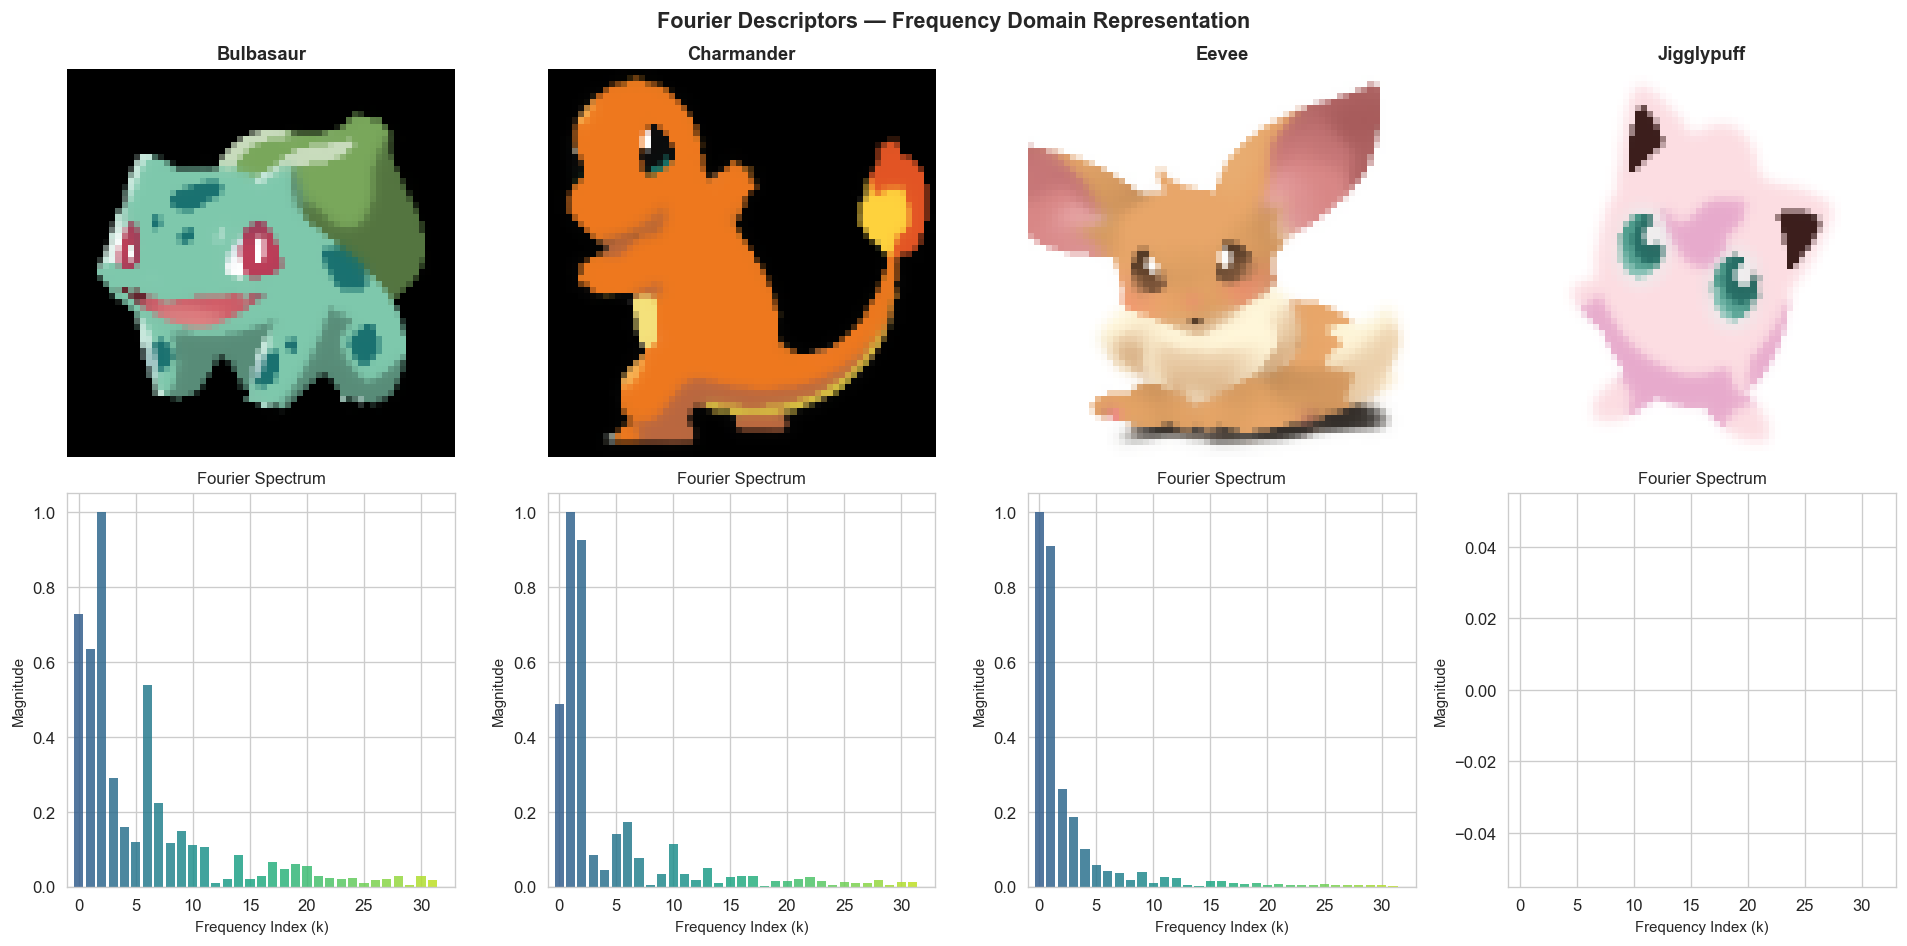

In [19]:
# ===== FOURIER SPECTRUM VISUALIZATION =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, path) in enumerate(sample_images[:4]):
    img = cv2.imread(path)
    img = cv2.resize(img, (128, 128))
    img = bilateral_denoise(img)
    img = cv2.resize(img, (64, 64))

    # Hiển thị ảnh
    axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"{name.capitalize()}", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    # Fourier Descriptors
    fd = get_fourier_descriptors(img, num_descriptors=32)
    axes[1, i].bar(range(len(fd)), fd, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(fd))),
                   edgecolor='none', alpha=0.85)
    axes[1, i].set_xlabel("Frequency Index (k)", fontsize=9)
    axes[1, i].set_ylabel("Magnitude", fontsize=9)
    axes[1, i].set_title(f"Fourier Spectrum", fontsize=10)
    axes[1, i].set_xlim(-1, 33)

plt.suptitle("Fourier Descriptors — Frequency Domain Representation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6.  HOG Features (Histogram of Oriented Gradients)

HOG mô tả **hình dạng và cấu trúc cạnh** thông qua phân bố hướng gradient:

### Các bước tính HOG:

1. **Gradient:** Tính $G_x$, $G_y$ bằng Sobel operator
2. **Magnitude & Orientation:**
$$M(x,y) = \sqrt{G_x^2 + G_y^2}, \quad \theta(x,y) = \arctan\frac{G_y}{G_x}$$
3. **Cell histogram:** Chia ảnh thành cell $8 \times 8$, tạo histogram 9 bins cho mỗi cell
4. **Block normalization:** Chuẩn hóa L2 trên block $2 \times 2$ cells

### Cấu hình trong project:

| Tham số | Giá trị | Ý nghĩa |
|---------|---------|----------|
| `orientations` | 9 | 9 bins hướng (0°–180°) |
| `pixels_per_cell` | (8, 8) | Kích thước mỗi cell |
| `cells_per_block` | (2, 2) | Block = 2×2 cells |
| Input size | 64×64 grayscale | Ảnh đã qua DSP preprocessing |


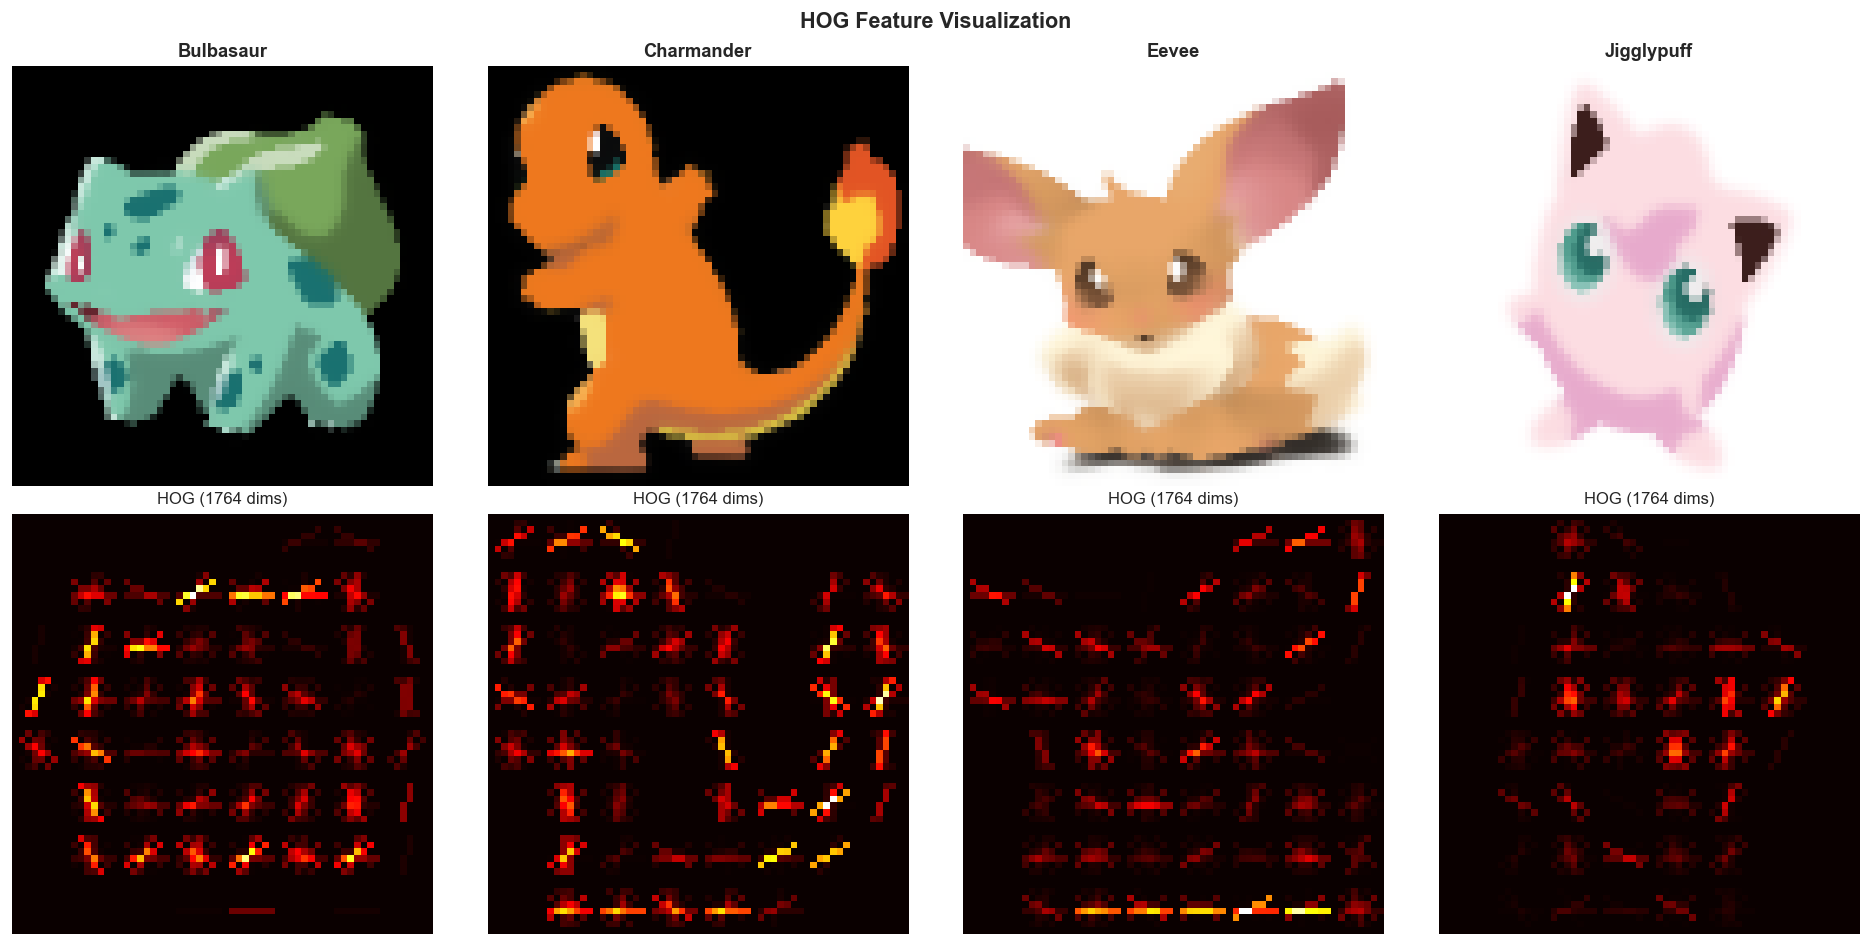

In [20]:
# ===== HOG VISUALIZATION =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, path) in enumerate(sample_images[:4]):
    img = extract_pokemon(path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog_feat, hog_img = hog(
        gray, orientations=9,
        pixels_per_cell=(8, 8), cells_per_block=(2, 2),
        visualize=True
    )

    axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"{name.capitalize()}", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(hog_img, cmap='hot')
    axes[1, i].set_title(f"HOG ({len(hog_feat)} dims)", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("HOG Feature Visualization", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7.  HSV Color Histogram

Không gian màu **HSV** (Hue-Saturation-Value) phù hợp hơn RGB cho nhận diện vì tách biệt **màu sắc** khỏi **độ sáng**:

- **H (Hue):** Màu sắc — 16 bins `[0, 180]` → quan trọng nhất
- **S (Saturation):** Độ bão hòa — 8 bins `[0, 256]`
- **V (Value):** Độ sáng — 8 bins `[0, 256]`

Histogram 3D được flatten thành vector $16 \times 8 \times 8 = 1024$ chiều, chuẩn hóa L2:

$$\hat{h} = \frac{h}{\|h\|_2}$$


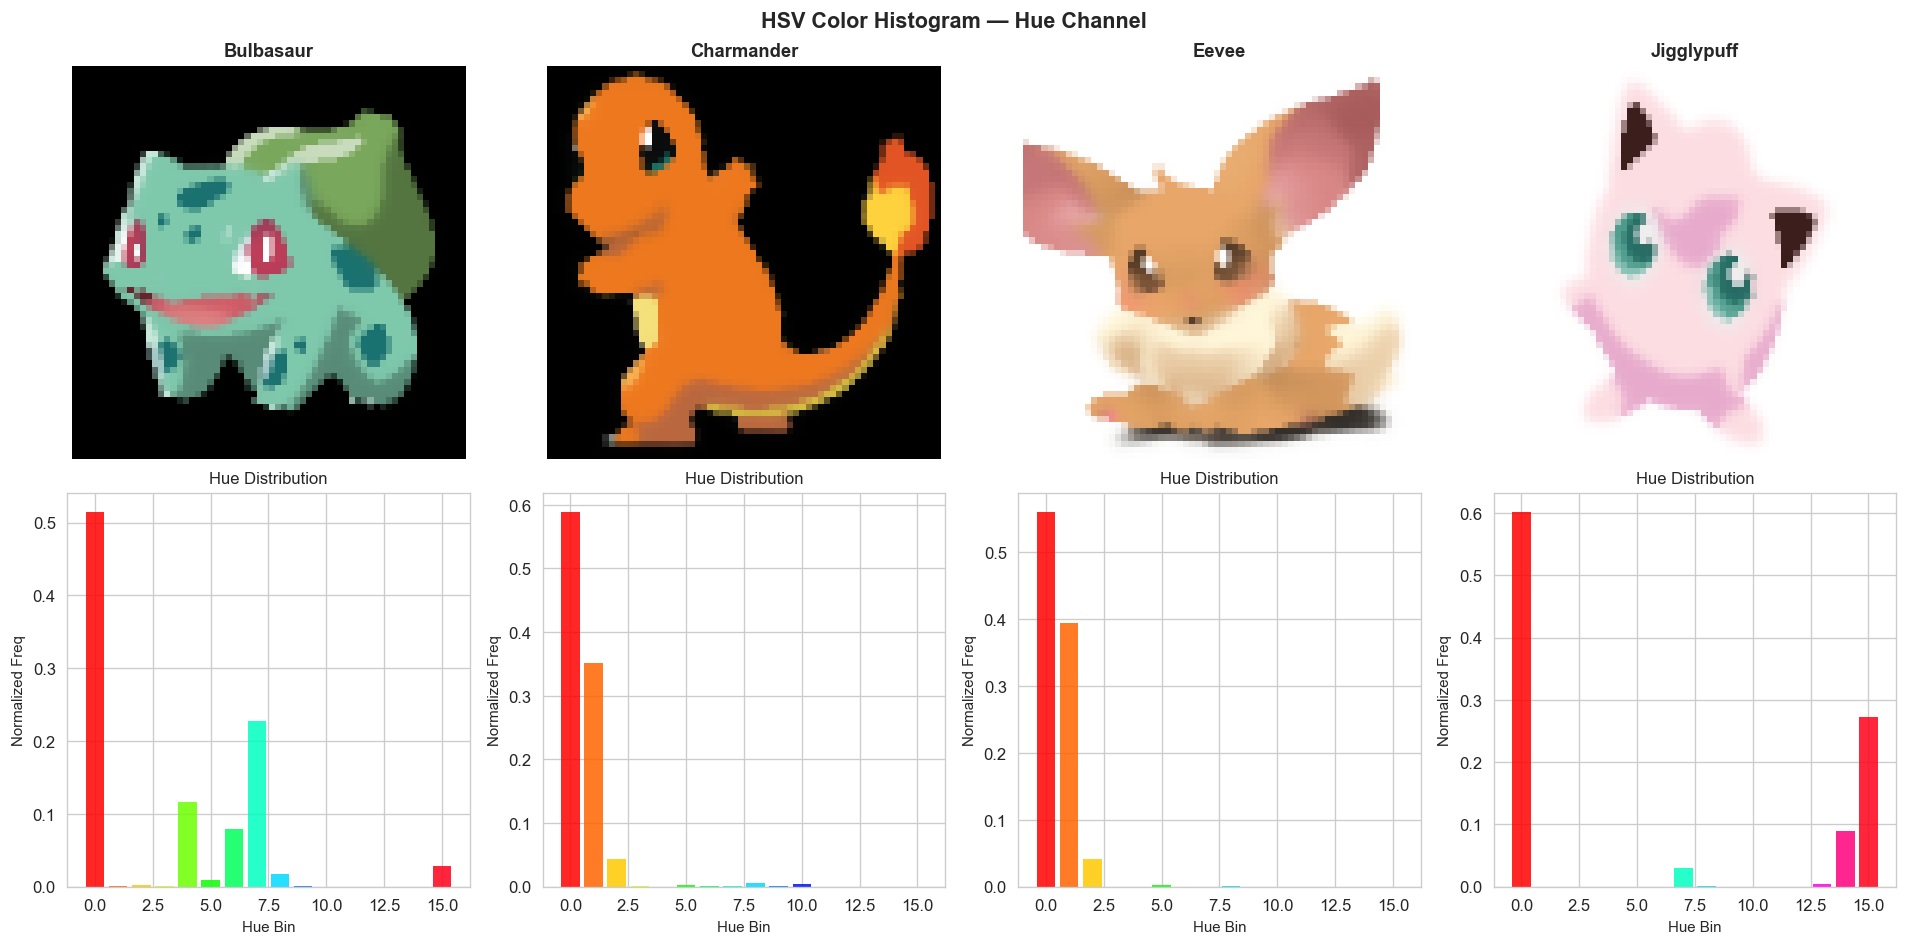

In [21]:
# ===== HSV HISTOGRAM VISUALIZATION =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

colors_h = plt.cm.hsv(np.linspace(0, 1, 16))

for i, (name, path) in enumerate(sample_images[:4]):
    img = extract_pokemon(path)
    if img is None:
        continue

    axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"{name.capitalize()}", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten()
    h_hist = h_hist / h_hist.sum()

    axes[1, i].bar(range(16), h_hist, color=colors_h, edgecolor='none', alpha=0.85)
    axes[1, i].set_xlabel("Hue Bin", fontsize=9)
    axes[1, i].set_ylabel("Normalized Freq", fontsize=9)
    axes[1, i].set_title("Hue Distribution", fontsize=10)

plt.suptitle("HSV Color Histogram — Hue Channel", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.  Tổng hợp Vector Đặc trưng

Feature vector cuối cùng là phép **concatenation** 3 nhóm đặc trưng:

$$\vec{f} = [\vec{f}_{HOG} \;\|\; \vec{f}_{HSV} \;\|\; \vec{f}_{FD}]$$

| Thành phần | Kích thước | Mô tả |
|------------|-----------|-------|
| HOG | ~1764 dims | Cấu trúc cạnh & texture |
| HSV Histogram | 1024 dims | Phân bố màu sắc |
| Fourier Descriptors | 32 dims | Hình dạng contour (DSP) |
| **Tổng** | **~2820 dims** | Vector đầu vào cho SVM |

> `StandardScaler` trong bước training sẽ cân bằng scale giữa 3 nhóm feature.


In [22]:
# ===== FEATURE EXTRACTION FUNCTIONS =====

def extract_feature_components(img):
    """Trích xuất 3 nhóm đặc trưng riêng biệt"""
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=False)

    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [16, 8, 8],
                        [0, 180, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist, norm_type=cv2.NORM_L2).flatten()

    fd_feat = get_fourier_descriptors(img, num_descriptors=32)

    return hog_feat, hist, fd_feat


def extract_features(img):
    """Tổng hợp thành 1 vector duy nhất"""
    hog_feat, hist, fd_feat = extract_feature_components(img)
    return np.hstack([hog_feat, hist, fd_feat])


# Demo
demo_img = extract_pokemon(sample_images[0][1])
hog_f, hist_f, fd_f = extract_feature_components(demo_img)
full_feat = extract_features(demo_img)

print(f" Feature extraction hoàn tất!")
print(f"   HOG:     {hog_f.shape[0]} dims")
print(f"   HSV:     {hist_f.shape[0]} dims")
print(f"   Fourier: {fd_f.shape[0]} dims")
print(f"   ─────────────────────")
print(f"   TOTAL:   {full_feat.shape[0]} dims")


 Feature extraction hoàn tất!
   HOG:     1764 dims
   HSV:     1024 dims
   Fourier: 32 dims
   ─────────────────────
   TOTAL:   2820 dims


## 9.  Data Augmentation

Mỗi ảnh gốc được tạo **11 biến thể** (bao gồm ảnh gốc) để tăng dữ liệu:

### Hình học (7 biến thể):
1. **Original** — Ảnh gốc
2. **Flip ngang** — Lật gương
3. **Xoay +20°** — Rotation clockwise
4. **Xoay −20°** — Rotation counter-clockwise
5. **Scale 80%** — Zoom out
6. **Shear ngang** — Biến dạng cắt
7. **Translate →↓** — Dịch phải-xuống 8px
8. **Translate ←↑** — Dịch trái-lên 8px

### Màu sắc + Nhiễu (3 biến thể):
9. **Sáng hơn** — alpha=1.3, beta=+20
10. **Tối hơn** — alpha=0.7, beta=−20
11. **Gaussian noise** — σ=8


In [23]:
# ===== AUGMENTATION FUNCTION =====

def augment(img):
    """11 biến thể: hình học + màu sắc + nhiễu"""
    results = [img]
    h, w    = img.shape[:2]
    center  = (w // 2, h // 2)

    # Hình học
    results.append(cv2.flip(img, 1))

    M = cv2.getRotationMatrix2D(center, 20, 1.0)
    results.append(cv2.warpAffine(img, M, (w, h)))

    M = cv2.getRotationMatrix2D(center, -20, 1.0)
    results.append(cv2.warpAffine(img, M, (w, h)))

    M = cv2.getRotationMatrix2D(center, 0, 0.8)
    results.append(cv2.warpAffine(img, M, (w, h)))

    shear = np.float32([[1, 0.15, 0], [0, 1, 0]])
    results.append(cv2.warpAffine(img, shear, (w, h)))

    M = np.float32([[1, 0, 8], [0, 1, 8]])
    results.append(cv2.warpAffine(img, M, (w, h)))

    M = np.float32([[1, 0, -8], [0, 1, -8]])
    results.append(cv2.warpAffine(img, M, (w, h)))

    # Màu sắc
    results.append(cv2.convertScaleAbs(img, alpha=1.3, beta=20))
    results.append(cv2.convertScaleAbs(img, alpha=0.7, beta=-20))

    # Nhiễu Gaussian
    noise = np.random.normal(0, 8, img.shape).astype(np.int16)
    noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    results.append(noisy)

    return results

print(" Augmentation function đã sẵn sàng")


 Augmentation function đã sẵn sàng


### Visualization: Tất cả 11 biến thể Augmentation

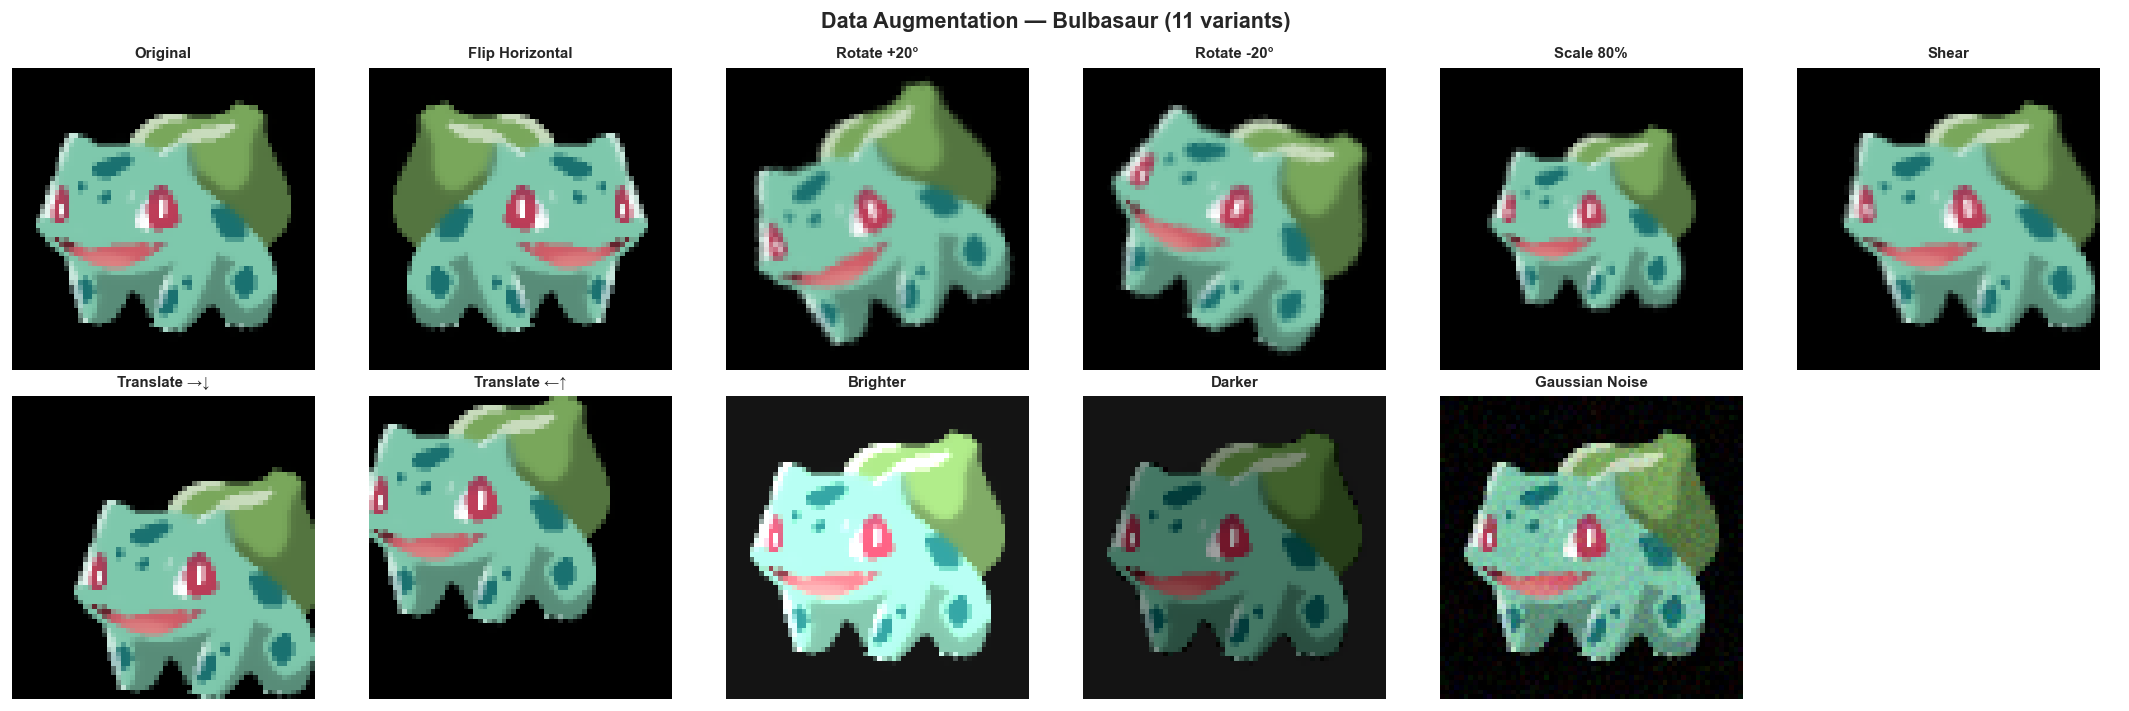

In [24]:
# ===== AUGMENTATION VISUALIZATION =====
demo_path = sample_images[0][1]
demo_name = sample_images[0][0]
demo_img  = extract_pokemon(demo_path)

aug_imgs = augment(demo_img)
aug_labels = [
    "Original", "Flip Horizontal", "Rotate +20°", "Rotate -20°",
    "Scale 80%", "Shear", "Translate →↓", "Translate ←↑",
    "Brighter", "Darker", "Gaussian Noise"
]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for i, (aug_img, label) in enumerate(zip(aug_imgs, aug_labels)):
    if i < len(axes):
        axes[i].imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(label, fontsize=9, fontweight='bold')
        axes[i].axis('off')

# Ẩn ô thừa
axes[-1].axis('off')

plt.suptitle(f"Data Augmentation — {demo_name.capitalize()} (11 variants)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10.  Load Dataset

Quá trình load dataset:
1. Duyệt từng thư mục class trong `data/`
2. Mỗi ảnh → `extract_pokemon()` (DSP preprocessing)
3. Mỗi ảnh → 11 augmented variants
4. Mỗi variant → `extract_features()` → feature vector
5. Lưu vào `X` (features) và `y` (labels)


In [25]:
# ===== LOAD DATASET =====

def load_dataset(data_dir):
    X, y     = [], []
    labels   = {}
    label_id = 0

    class_names = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])

    for class_name in class_names:
        class_path     = os.path.join(data_dir, class_name)
        labels[label_id] = class_name

        count = 0
        for file in os.listdir(class_path):
            path = os.path.join(class_path, file)
            img  = extract_pokemon(path)
            if img is None:
                continue
            for aug in augment(img):
                feat = extract_features(aug)
                X.append(feat)
                y.append(label_id)
                count += 1

        print(f"  {class_name}: {count} samples (sau augment)")
        label_id += 1

    print(f"\nTổng: {len(X)} samples, {len(labels)} classes")
    return np.array(X), np.array(y), labels


print("⏳ Đang load dataset... (có thể mất vài phút)")
X, y, labels = load_dataset(DATA_DIR)
print(f"\n Dataset shape: X={X.shape}, y={y.shape}")
print(f"   Classes: {list(labels.values())}")


⏳ Đang load dataset... (có thể mất vài phút)
  bulbasaur: 792 samples (sau augment)
  charmander: 836 samples (sau augment)
  eevee: 682 samples (sau augment)
  jigglypuff: 825 samples (sau augment)
  magikarp: 770 samples (sau augment)
  meowth: 583 samples (sau augment)
  pikachu: 968 samples (sau augment)
  psyduck: 748 samples (sau augment)
  snorlax: 968 samples (sau augment)
  squirtle: 924 samples (sau augment)

Tổng: 8096 samples, 10 classes

 Dataset shape: X=(8096, 2820), y=(8096,)
   Classes: ['bulbasaur', 'charmander', 'eevee', 'jigglypuff', 'magikarp', 'meowth', 'pikachu', 'psyduck', 'snorlax', 'squirtle']


## 11.  Train/Test Split

Chia dữ liệu theo tỷ lệ **80/20**, sử dụng `stratify` để đảm bảo phân bố class đều:


 Train: 6476 samples
   Val:   1620 samples
   Ratio: 80% / 20%


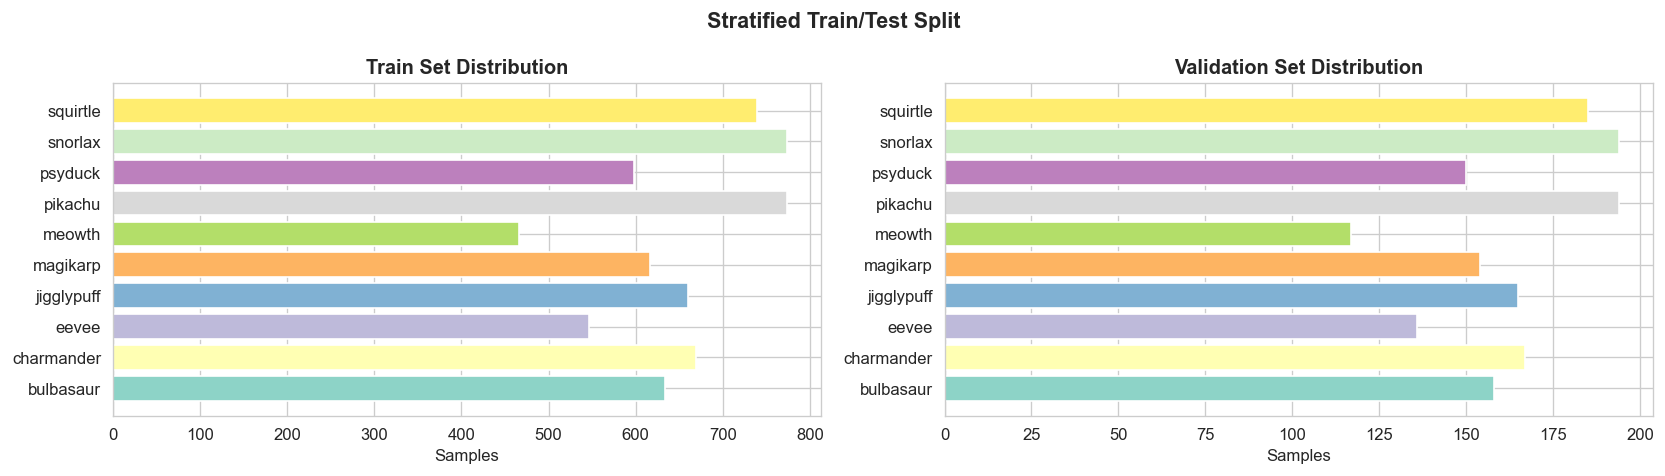

In [26]:
# ===== TRAIN/TEST SPLIT =====
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f" Train: {len(X_train)} samples")
print(f"   Val:   {len(X_val)} samples")
print(f"   Ratio: {len(X_train)/(len(X_train)+len(X_val))*100:.0f}% / {len(X_val)/(len(X_train)+len(X_val))*100:.0f}%")

# Phân bố class trong train set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

train_counts = np.bincount(y_train)
val_counts   = np.bincount(y_val)
class_names_list = [labels[i] for i in range(len(labels))]

ax1.barh(class_names_list, train_counts, color=plt.cm.Set3(np.linspace(0, 1, len(labels))))
ax1.set_title("Train Set Distribution", fontweight='bold')
ax1.set_xlabel("Samples")

ax2.barh(class_names_list, val_counts, color=plt.cm.Set3(np.linspace(0, 1, len(labels))))
ax2.set_title("Validation Set Distribution", fontweight='bold')
ax2.set_xlabel("Samples")

plt.suptitle("Stratified Train/Test Split", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 12.  StandardScaler

Chuẩn hóa feature về **mean=0, std=1** để SVM hoạt động tốt hơn:

$$z = \frac{x - \mu}{\sigma}$$

> **Tránh data leakage:** `fit_transform` chỉ trên train, `transform` trên validation.


In [27]:
# ===== STANDARD SCALER =====
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(" StandardScaler đã fit trên train set")
print(f"   Mean range:  [{X_train.mean(axis=0).min():.4f}, {X_train.mean(axis=0).max():.4f}]")
print(f"   Std range:   [{X_train.std(axis=0).min():.4f}, {X_train.std(axis=0).max():.4f}]")


 StandardScaler đã fit trên train set
   Mean range:  [-0.0000, 0.0000]
   Std range:   [0.0000, 1.0000]


## 13.  GridSearchCV — Hyperparameter Tuning

**GridSearchCV** tìm bộ tham số tối ưu cho SVM bằng cách thử tất cả tổ hợp:

| Tham số | Giá trị thử | Ý nghĩa |
|---------|------------|----------|
| `C` | [10, 100] | Regularization strength |
| `gamma` | ['scale'] | RBF kernel coefficient |
| `kernel` | ['rbf'] | Radial Basis Function |

**Cross-validation:** 3-fold trên subset 2000 samples (tốc độ nhanh).

### RBF Kernel:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$


In [28]:
# ===== GRIDSEARCHCV =====
def create_base_model():
    return SVC(probability=True, class_weight='balanced')

model = create_base_model()

# Giảm data để tune nhanh
subset_size = min(2000, len(X_train))
X_small = X_train[:subset_size]
y_small = y_train[:subset_size]

param_grid = {
    'C': [10, 100],
    'gamma': ['scale'],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    model, param_grid,
    cv=3, verbose=2,
    n_jobs=-1, scoring='accuracy'
)

print(f"⏳ GridSearch trên {subset_size} samples...")
grid.fit(X_small, y_small)

print(f"\n Best params: {grid.best_params_}")
print(f"   Best CV score: {grid.best_score_*100:.2f}%")


⏳ GridSearch trên 2000 samples...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

 Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Best CV score: 86.75%


## 14.  Train SVM (Full Dataset)

Sau khi tìm được hyperparameters tối ưu, train lại trên **toàn bộ** training set:


In [29]:
# ===== TRAIN FULL =====
best_model = grid.best_estimator_

print(" Training lại trên full dataset...")
best_model.fit(X_train, y_train)
print(f" Training hoàn tất! Support vectors: {best_model.n_support_.sum()}")


 Training lại trên full dataset...
 Training hoàn tất! Support vectors: 5348


## 15.  Predict ảnh mới

Sử dụng model đã train để dự đoán trên validation set:


In [30]:
# ===== PREDICTION =====
y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)

# Hiển thị một số kết quả
print(" Một số kết quả dự đoán:")
print(f"{'Index':<8} {'Actual':<15} {'Predicted':<15} {'Confidence':<12} {'✓/✗'}")
print("─" * 55)

for i in range(min(15, len(y_val))):
    actual  = labels[y_val[i]]
    predict = labels[y_pred[i]]
    conf    = max(y_prob[i]) * 100
    status  = "[V]" if y_val[i] == y_pred[i] else "[X]"
    print(f"{i:<8} {actual:<15} {predict:<15} {conf:<12.1f} {status}")


 Một số kết quả dự đoán:
Index    Actual          Predicted       Confidence   ✓/✗
───────────────────────────────────────────────────────
0        eevee           eevee           97.5         [V]
1        bulbasaur       bulbasaur       99.9         [V]
2        snorlax         snorlax         99.7         [V]
3        psyduck         psyduck         95.5         [V]
4        meowth          meowth          100.0        [V]
5        bulbasaur       bulbasaur       97.8         [V]
6        magikarp        magikarp        99.4         [V]
7        squirtle        squirtle        99.2         [V]
8        snorlax         snorlax         99.0         [V]
9        eevee           eevee           100.0        [V]
10       bulbasaur       bulbasaur       97.0         [V]
11       eevee           eevee           80.0         [V]
12       charmander      charmander      99.9         [V]
13       eevee           eevee           94.9         [V]
14       magikarp        magikarp        99.5    

## 16.  Evaluation — Đánh giá mô hình

### Các metrics đánh giá:

| Metric | Công thức | Ý nghĩa |
|--------|-----------|----------|
| **Accuracy** | $\frac{TP+TN}{Total}$ | Tỷ lệ dự đoán đúng tổng thể |
| **Precision** | $\frac{TP}{TP+FP}$ | Trong các dự đoán positive, bao nhiêu đúng? |
| **Recall** | $\frac{TP}{TP+FN}$ | Trong các positive thật, bao nhiêu được tìm ra? |
| **F1-score** | $2 \cdot \frac{P \cdot R}{P + R}$ | Trung bình điều hòa Precision & Recall |


In [31]:
# ===== EVALUATION METRICS =====
acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average='weighted')
rec  = recall_score(y_val, y_pred, average='weighted')
f1   = f1_score(y_val, y_pred, average='weighted')

print("╔══════════════════════════════════════╗")
print("║      MODEL EVALUATION RESULTS      ║")
print("╠══════════════════════════════════════╣")
print(f"║  Accuracy:   {acc*100:>6.2f}%                ║")
print(f"║  Precision:  {prec*100:>6.2f}%                ║")
print(f"║  Recall:     {rec*100:>6.2f}%                ║")
print(f"║  F1-Score:   {f1*100:>6.2f}%                ║")
print("╚══════════════════════════════════════╝")


╔══════════════════════════════════════╗
║      MODEL EVALUATION RESULTS      ║
╠══════════════════════════════════════╣
║  Accuracy:    95.68%                ║
║  Precision:   96.02%                ║
║  Recall:      95.68%                ║
║  F1-Score:    95.74%                ║
╚══════════════════════════════════════╝


### Classification Report (Per-class)

In [32]:
# ===== CLASSIFICATION REPORT =====
report = classification_report(
    y_val, y_pred,
    target_names=[labels[i] for i in sorted(labels)]
)
print(report)


              precision    recall  f1-score   support

   bulbasaur       0.99      0.93      0.96       158
  charmander       0.95      0.96      0.96       167
       eevee       0.99      0.96      0.97       136
  jigglypuff       0.99      0.95      0.97       165
    magikarp       0.96      0.95      0.95       154
      meowth       0.99      0.89      0.94       117
     pikachu       0.98      0.98      0.98       194
     psyduck       0.97      0.96      0.97       150
     snorlax       0.83      0.98      0.90       194
    squirtle       0.98      0.98      0.98       185

    accuracy                           0.96      1620
   macro avg       0.96      0.95      0.96      1620
weighted avg       0.96      0.96      0.96      1620



### Confusion Matrix Heatmap

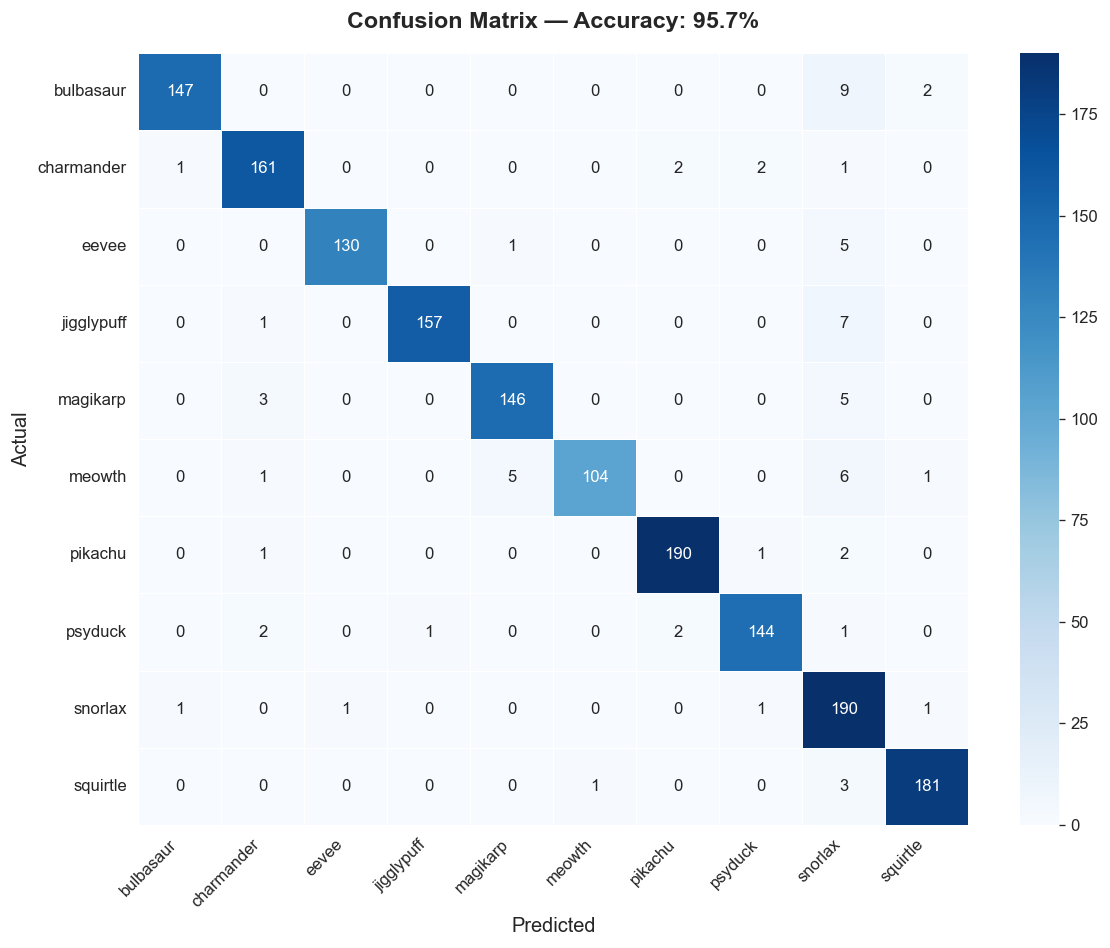

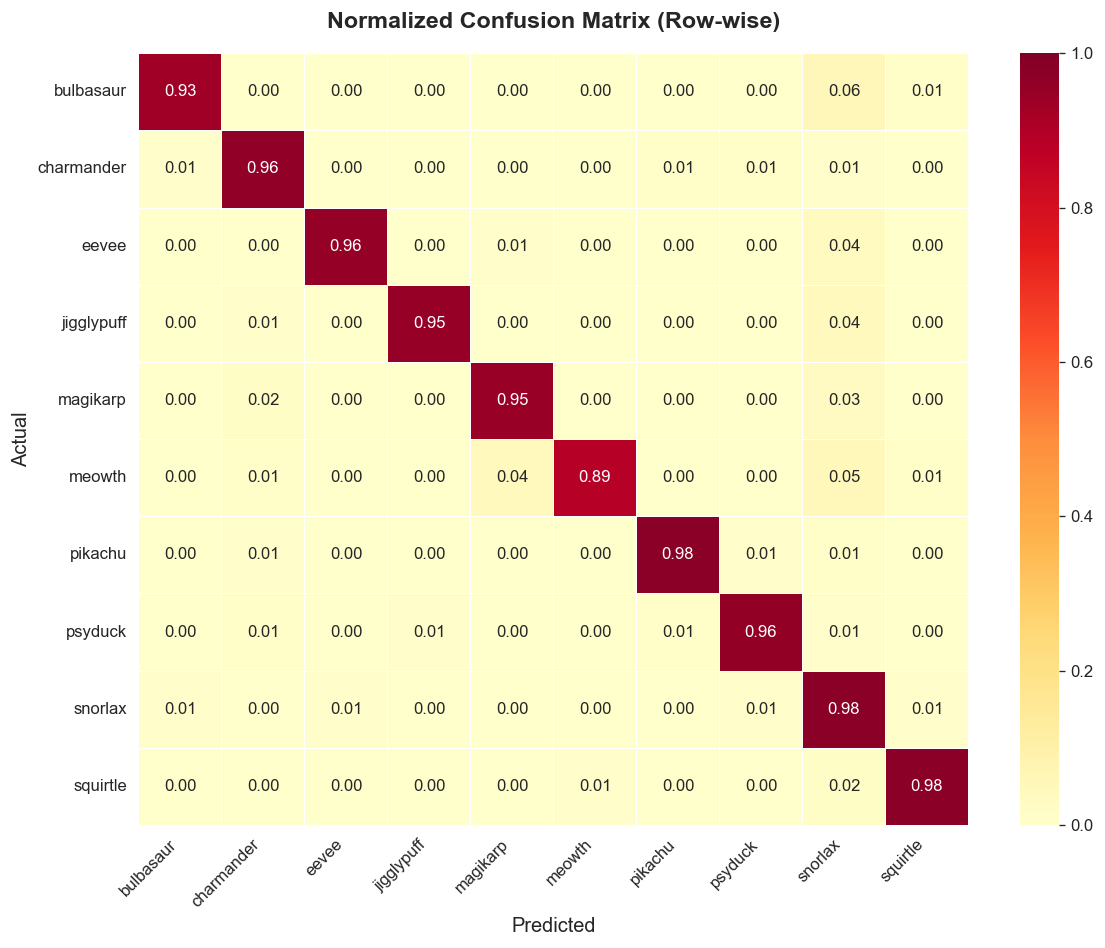

In [33]:
# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_val, y_pred)
class_names_sorted = [labels[i] for i in sorted(labels)]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names_sorted,
    yticklabels=class_names_sorted,
    linewidths=0.5, linecolor='white',
    ax=ax
)

ax.set_title(f"Confusion Matrix — Accuracy: {acc*100:.1f}%",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=class_names_sorted,
    yticklabels=class_names_sorted,
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, ax=ax
)

ax.set_title("Normalized Confusion Matrix (Row-wise)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 17.  Save Model

Lưu 3 file vào thư mục `Model/`:
- `model.pkl` — SVM model đã train
- `labels.pkl` — Mapping label_id → class_name
- `scaler.pkl` — StandardScaler đã fit


In [34]:
# ===== SAVE MODEL =====
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(MODEL_DIR, "model.pkl"))
joblib.dump(labels,     os.path.join(MODEL_DIR, "labels.pkl"))
joblib.dump(scaler,     os.path.join(MODEL_DIR, "scaler.pkl"))

print(" Đã lưu model vào Model/")
for f in os.listdir(MODEL_DIR):
    fpath = os.path.join(MODEL_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"   {f}: {size:.1f} KB")


 Đã lưu model vào Model/
   centroids.pkl: 182.3 KB
   labels.pkl: 0.1 KB
   model.pkl: 118599.6 KB
   scaler.pkl: 66.7 KB


## 18.  Demo Inference Realtime

Sử dụng model đã lưu để predict ảnh mới từ thư mục `Test/` hoặc bất kỳ ảnh nào:


 DEMO INFERENCE REALTIME
  bulbasaur    → bulbasaur    (100.0%) [V]
  charmander   → charmander   (100.0%) [V]
  eevee        → eevee        (100.0%) [V]
  jigglypuff   → jigglypuff   (100.0%) [V]
  magikarp     → magikarp     (100.0%) [V]
  meowth       → meowth       (100.0%) [V]
  pikachu      → pikachu      (100.0%) [V]
  psyduck      → psyduck      (100.0%) [V]
  snorlax      → snorlax      (99.9%) [V]
  squirtle     → squirtle     (100.0%) [V]


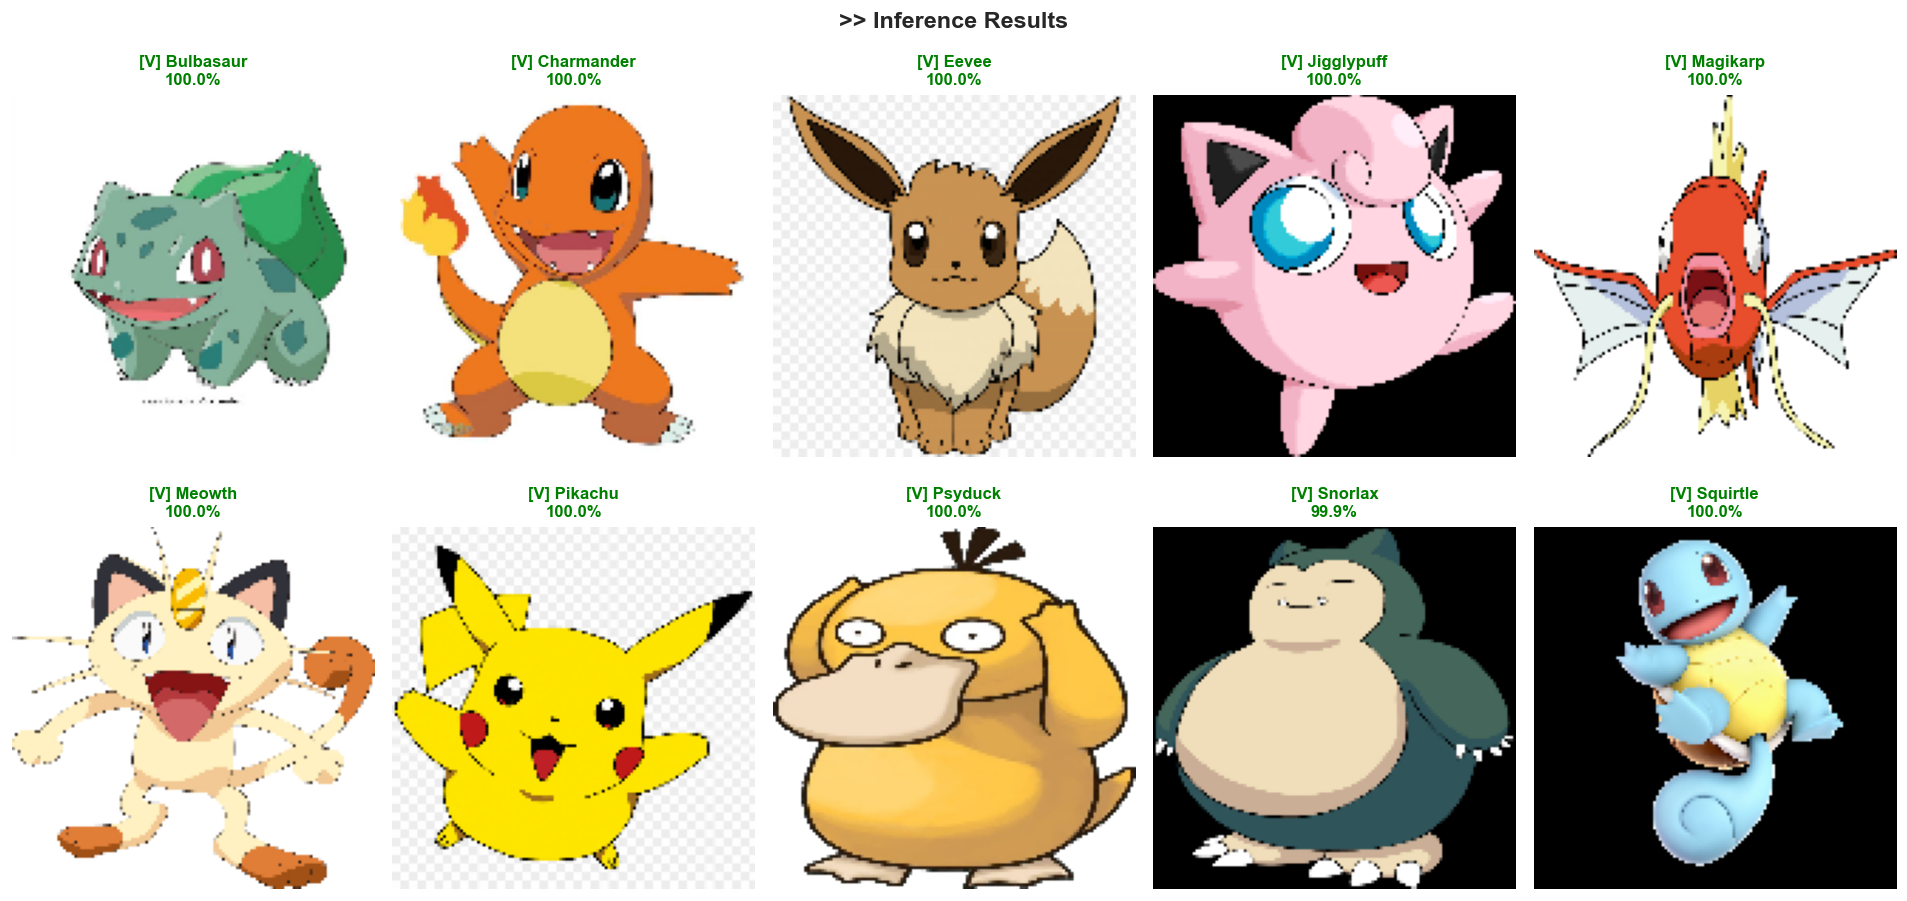

In [35]:
# ===== DEMO INFERENCE =====

def predict_single(image_path, model, scaler, labels):
    """Predict một ảnh duy nhất"""
    img = extract_pokemon(image_path)
    if img is None:
        return "Không đọc được ảnh", 0.0

    feat = extract_features(img)
    feat_scaled = scaler.transform([feat])

    pred = model.predict(feat_scaled)[0]
    prob = model.predict_proba(feat_scaled)[0]

    return labels[pred], float(max(prob))


# Demo trên ảnh từ dataset (1 ảnh mỗi class)
print(" DEMO INFERENCE REALTIME")
print("=" * 50)

test_samples = []
for name, path in sample_images:
    class_path = os.path.join(DATA_DIR, name)
    files = os.listdir(class_path)
    if len(files) > 1:
        test_samples.append((name, os.path.join(class_path, files[-1])))
    else:
        test_samples.append((name, path))

# Hiển thị grid kết quả
n_samples = min(len(test_samples), 10)
cols = 5
rows = (n_samples + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)

for i in range(n_samples):
    name, path = test_samples[i]
    pred_name, confidence = predict_single(path, best_model, scaler, labels)

    img = cv2.imread(path)
    img = cv2.resize(img, (128, 128))

    r, c = i // cols, i % cols
    axes[r, c].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    is_correct = pred_name == name
    color = 'green' if is_correct else 'red'
    icon  = '[V]' if is_correct else '[X]'

    axes[r, c].set_title(
        f"{icon} {pred_name.capitalize()}\n{confidence*100:.1f}%",
        fontsize=10, fontweight='bold', color=color
    )
    axes[r, c].axis('off')

    print(f"  {name:<12} → {pred_name:<12} ({confidence*100:.1f}%) {icon}")

# Ẩn ô thừa
for i in range(n_samples, rows * cols):
    r, c = i // cols, i % cols
    axes[r, c].axis('off')

plt.suptitle(">> Inference Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##  Kết luận

### Pipeline hoàn chỉnh:

1. **DSP Preprocessing:** Median Blur + Bilateral Filter khử nhiễu hiệu quả, giữ cạnh
2. **Feature Extraction:**
   - Fourier Descriptors (32D) — hình dạng contour qua biến đổi FFT
   - HOG Features (~1764D) — cấu trúc gradient và texture
   - HSV Histogram (1024D) — phân bố màu sắc
3. **Data Augmentation:** 11 biến thể/ảnh tăng cường dữ liệu
4. **SVM + RBF Kernel:** Phân loại hiệu quả trong không gian đặc trưng cao chiều
5. **GridSearchCV:** Tự động tìm hyperparameters tối ưu

### Điểm mạnh DSP:
- Fourier Descriptors là phương pháp **xử lý tín hiệu số** kinh điển cho mô tả hình dạng
- **Scale invariant** và **rotation robust** nhờ chuẩn hóa phổ tần số
- Low-pass filtering trên contour loại bỏ nhiễu chi tiết, giữ đặc trưng tổng thể




## 19.  So sánh khử nhiễu: DSP (Bilateral) vs Deep Learning (U-Net)

### PSNR & SSIM — Hai thước đo chất lượng ảnh

**PSNR (Peak Signal-to-Noise Ratio)** — đo lượng nhiễu còn lại:

$$PSNR = 10 \cdot \log_{10}\!\left(\frac{MAX_I^2}{MSE}\right) \quad \text{(dB)}$$

$$MSE = \frac{1}{MN}\sum_{i=0}^{M-1}\sum_{j=0}^{N-1}\left[I(i,j) - K(i,j)\right]^2$$

- PSNR **càng cao** → ảnh càng ít nhiễu (> 30 dB là tốt)

**SSIM (Structural Similarity Index)** — đo độ giống cấu trúc:

$$SSIM(x,y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$$

- SSIM ∈ [0, 1], **càng gần 1** → cấu trúc càng được bảo toàn

### Thiết kế thí nghiệm

| Thư mục | Nội dung |
|---------|----------|
| `Danh_gia/goc/` | Ảnh gốc + ảnh đã thêm 3 loại nhiễu (Gaussian, Salt&Pepper, Speckle) |
| `Danh_gia/dsp/` | Ảnh khử nhiễu bằng **DSP** (Median + Bilateral Filter) |
| `Danh_gia/unet/` | Ảnh khử nhiễu bằng **Deep Learning** (U-Net Autoencoder) |

So sánh: Lấy ảnh nhiễu trong `goc/` làm **reference**, đo PSNR/SSIM của kết quả DSP và U-Net.


In [1]:
# ===== PSNR / SSIM EVALUATION =====
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

DIR_GOC  = "Danh_gia/goc"
DIR_DSP  = "Danh_gia/dsp"
DIR_UNET = "Danh_gia/unet"

NOISE_TYPES = ["gaussian", "saltpepper", "speckle"]
IMG_EXTS    = [".png", ".jpg", ".jpeg", ".bmp"]


def find_file(directory, stem):
    for ext in IMG_EXTS:
        path = os.path.join(directory, stem + ext)
        if os.path.isfile(path):
            return path
    return None


def read_img(path):
    img = cv2.imread(path)
    if img is not None and img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    return img


def resize_to_match(ref, target):
    if ref.shape != target.shape:
        h, w = ref.shape[:2]
        target = cv2.resize(target, (w, h), interpolation=cv2.INTER_AREA)
    return target


def calc_metrics(ref, test):
    test = resize_to_match(ref, test)
    p = compute_psnr(ref, test, data_range=255)
    s = compute_ssim(ref, test, data_range=255, channel_axis=2)
    return p, s


# --- Thu thap ket qua ---
results = {n: [] for n in NOISE_TYPES}

for fname in sorted(os.listdir(DIR_GOC)):
    stem, ext = os.path.splitext(fname)
    if ext.lower() not in IMG_EXTS:
        continue

    noise_found = None
    for noise in NOISE_TYPES:
        if stem.endswith(f"_{noise}"):
            noise_found = noise
            break
    if noise_found is None:
        continue

    path_goc  = find_file(DIR_GOC, stem)
    path_dsp  = find_file(DIR_DSP, stem)
    path_unet = find_file(DIR_UNET, stem)

    if path_goc is None or path_dsp is None or path_unet is None:
        continue

    img_goc  = read_img(path_goc)
    img_dsp  = read_img(path_dsp)
    img_unet = read_img(path_unet)

    if img_goc is None or img_dsp is None or img_unet is None:
        continue

    p_dsp,  s_dsp  = calc_metrics(img_goc, img_dsp)
    p_unet, s_unet = calc_metrics(img_goc, img_unet)

    results[noise_found].append({
        "file": stem, "psnr_dsp": p_dsp, "ssim_dsp": s_dsp,
        "psnr_unet": p_unet, "ssim_unet": s_unet,
    })

print("Thu thap xong ket qua!")
total = sum(len(v) for v in results.values())
for n in NOISE_TYPES:
    print(f"   {n}: {len(results[n])} images")
print(f"   Total: {total} images")

Thu thap xong ket qua!
   gaussian: 7 images
   saltpepper: 7 images
   speckle: 7 images
   Total: 21 images


### Kết quả chi tiết theo loại nhiễu

In [3]:
# ===== BANG KET QUA CHI TIET =====
label_map = {"gaussian": "Gaussian", "saltpepper": "Salt & Pepper", "speckle": "Speckle"}

all_psnr_dsp, all_ssim_dsp   = [], []
all_psnr_unet, all_ssim_unet = [], []

for noise in NOISE_TYPES:
    rows = results[noise]
    if not rows:
        continue

    print(f"\n{'='*80}")
    print(f"  Loai nhieu: {label_map[noise]}  ({len(rows)} anh)")
    print(f"{'='*80}")
    print(f"{'File':<35} {'PSNR_DSP':>10} {'SSIM_DSP':>10} {'PSNR_UNet':>10} {'SSIM_UNet':>10}")
    print("-" * 80)

    for r in rows:
        print(f"{r['file']:<35} {r['psnr_dsp']:>10.2f} {r['ssim_dsp']:>10.4f}"
              f" {r['psnr_unet']:>10.2f} {r['ssim_unet']:>10.4f}")

        all_psnr_dsp.append(r['psnr_dsp']);   all_ssim_dsp.append(r['ssim_dsp'])
        all_psnr_unet.append(r['psnr_unet']); all_ssim_unet.append(r['ssim_unet'])

    print("-" * 80)
    psnr_d = np.mean([r['psnr_dsp'] for r in rows])
    ssim_d = np.mean([r['ssim_dsp'] for r in rows])
    psnr_u = np.mean([r['psnr_unet'] for r in rows])
    ssim_u = np.mean([r['ssim_unet'] for r in rows])
    print(f"{'Trung binh':<35} {psnr_d:>10.2f} {ssim_d:>10.4f} {psnr_u:>10.2f} {ssim_u:>10.4f}")



  Loai nhieu: Gaussian  (7 anh)
File                                  PSNR_DSP   SSIM_DSP  PSNR_UNet  SSIM_UNet
--------------------------------------------------------------------------------
bulara_gaussian                          19.05     0.3982      17.82     0.4657
evee_gaussian                            20.81     0.5303      20.60     0.4830
pikachu2_gaussian                        22.03     0.4988      20.27     0.4267
pikachu_gaussian                         20.52     0.3704      20.25     0.4090
snorlax_gaussian                         22.46     0.5369      21.47     0.5739
squirtle 2_gaussian                      18.92     0.4317      19.23     0.5166
squirtle_gaussian                        16.64     0.3677      18.12     0.4899
--------------------------------------------------------------------------------
Trung binh                               20.06     0.4477      19.68     0.4807

  Loai nhieu: Salt & Pepper  (7 anh)
File                                  PSNR_DSP 

### Tổng hợp & Biểu đồ so sánh

In [4]:
# ===== TONG HOP =====
mean_psnr_dsp  = np.mean(all_psnr_dsp)
mean_ssim_dsp  = np.mean(all_ssim_dsp)
mean_psnr_unet = np.mean(all_psnr_unet)
mean_ssim_unet = np.mean(all_ssim_unet)

print("+" + "="*50 + "+")
print("|        TONG HOP DANH GIA KHU NHIEU            |")
print("+" + "="*50 + "+")
print(f"|  {'Method':<25} {'PSNR (dB)':>10} {'SSIM':>10}  |")
print("|" + "-"*50 + "|")
print(f"|  {'DSP (Bilateral)':<25} {mean_psnr_dsp:>10.2f} {mean_ssim_dsp:>10.4f}  |")
print(f"|  {'UNet (Deep Learning)':<25} {mean_psnr_unet:>10.2f} {mean_ssim_unet:>10.4f}  |")
print("+" + "="*50 + "+")

winner_p = "U-Net" if mean_psnr_unet > mean_psnr_dsp else "DSP"
winner_s = "U-Net" if mean_ssim_unet > mean_ssim_dsp else "DSP"
print(f"\n  >> PSNR tot hon: {winner_p}")
print(f"  >> SSIM tot hon: {winner_s}")


+==================================================+
|        TONG HOP DANH GIA KHU NHIEU            |
+==================================================+
|  Method                     PSNR (dB)       SSIM  |
|--------------------------------------------------|
|  DSP (Bilateral)                19.09     0.4807  |
|  UNet (Deep Learning)           18.93     0.5045  |
+==================================================+

  >> PSNR tot hon: DSP
  >> SSIM tot hon: U-Net


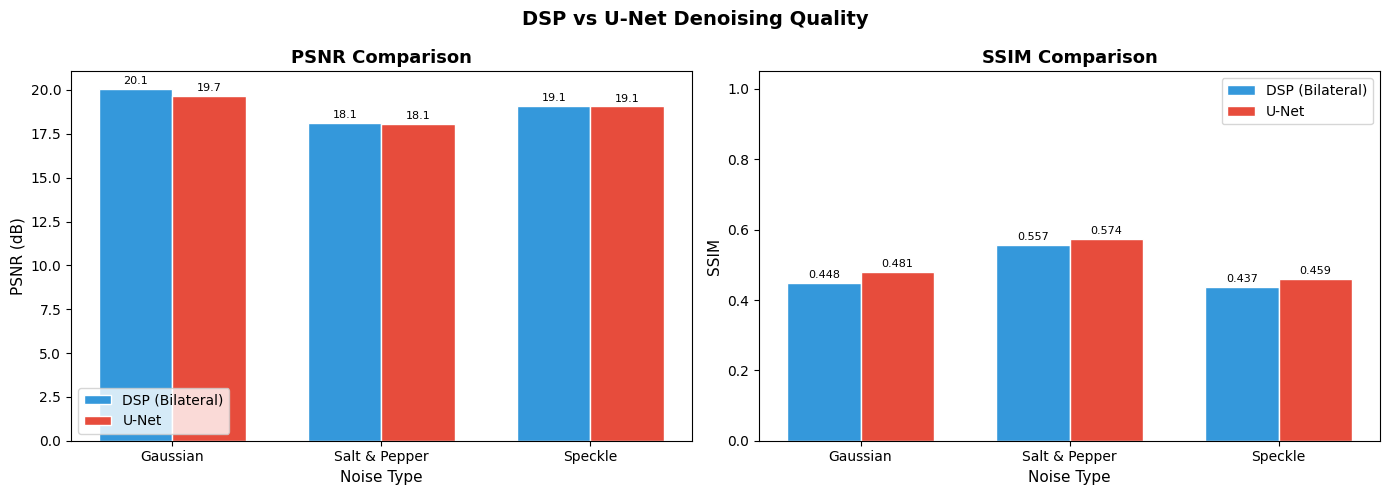

In [5]:
# ===== BAR CHART SO SANH =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PSNR per noise type ---
x = np.arange(len(NOISE_TYPES))
width = 0.35
psnr_dsp_avg  = [np.mean([r['psnr_dsp']  for r in results[n]]) if results[n] else 0 for n in NOISE_TYPES]
psnr_unet_avg = [np.mean([r['psnr_unet'] for r in results[n]]) if results[n] else 0 for n in NOISE_TYPES]

bars1 = axes[0].bar(x - width/2, psnr_dsp_avg,  width, label='DSP (Bilateral)', color='#3498db', edgecolor='white')
bars2 = axes[0].bar(x + width/2, psnr_unet_avg, width, label='U-Net',           color='#e74c3c', edgecolor='white')
axes[0].set_xlabel("Noise Type", fontsize=11)
axes[0].set_ylabel("PSNR (dB)", fontsize=11)
axes[0].set_title("PSNR Comparison", fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([label_map[n] for n in NOISE_TYPES])
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.1f', fontsize=8, padding=2)
axes[0].bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)

# --- SSIM per noise type ---
ssim_dsp_avg  = [np.mean([r['ssim_dsp']  for r in results[n]]) if results[n] else 0 for n in NOISE_TYPES]
ssim_unet_avg = [np.mean([r['ssim_unet'] for r in results[n]]) if results[n] else 0 for n in NOISE_TYPES]

bars3 = axes[1].bar(x - width/2, ssim_dsp_avg,  width, label='DSP (Bilateral)', color='#3498db', edgecolor='white')
bars4 = axes[1].bar(x + width/2, ssim_unet_avg, width, label='U-Net',           color='#e74c3c', edgecolor='white')
axes[1].set_xlabel("Noise Type", fontsize=11)
axes[1].set_ylabel("SSIM", fontsize=11)
axes[1].set_title("SSIM Comparison", fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([label_map[n] for n in NOISE_TYPES])
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].bar_label(bars3, fmt='%.3f', fontsize=8, padding=2)
axes[1].bar_label(bars4, fmt='%.3f', fontsize=8, padding=2)

plt.suptitle("DSP vs U-Net Denoising Quality", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### So sánh trực quan: Ảnh nhiễu → DSP → U-Net

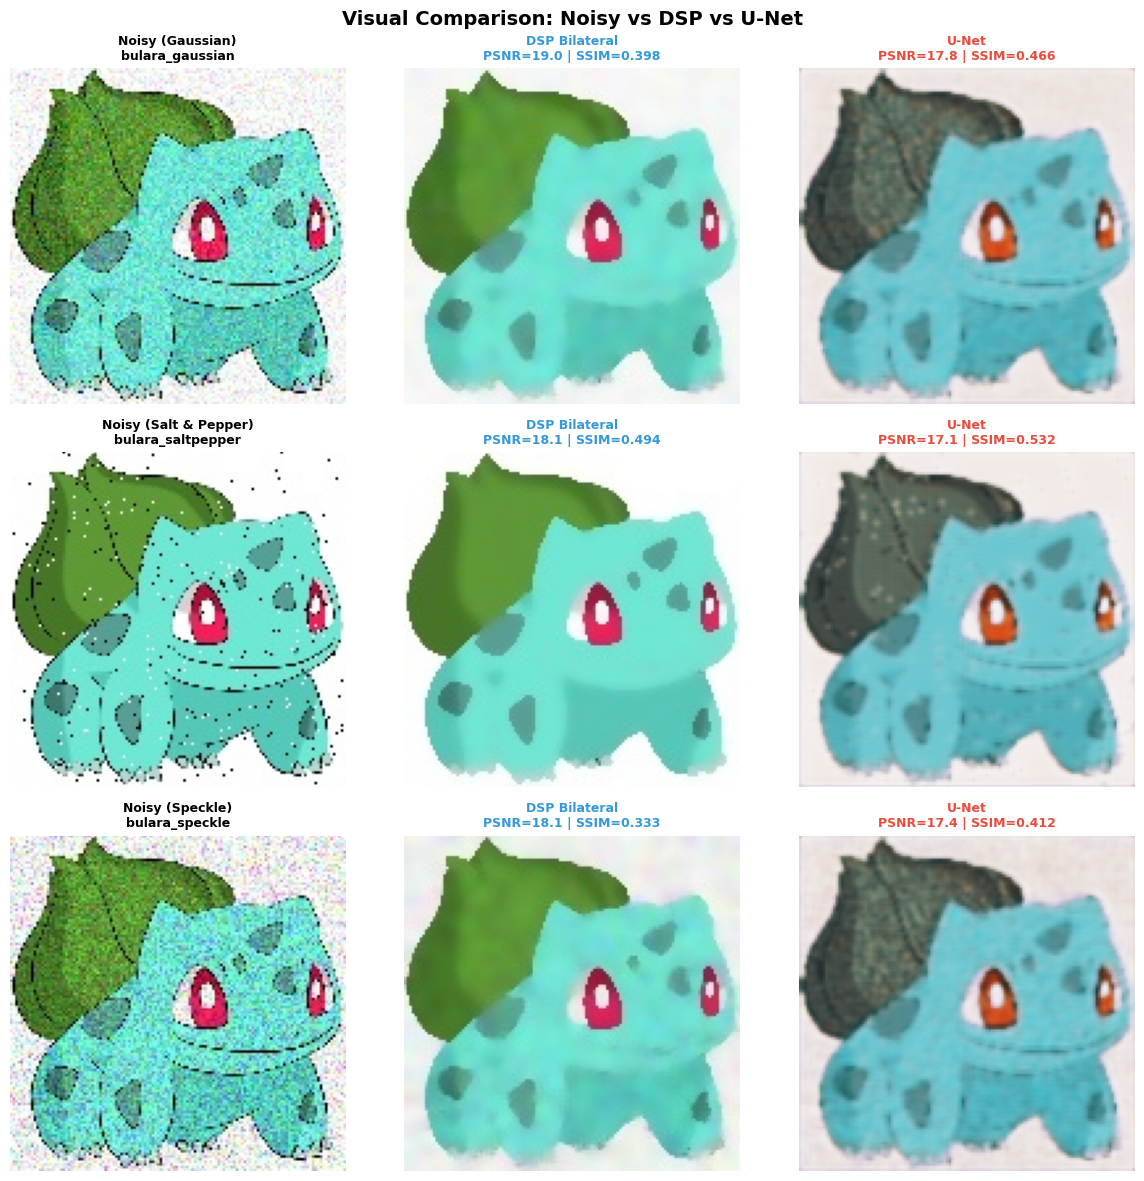

In [6]:
# ===== VISUAL COMPARISON =====
# Lay 1 anh moi loai nhieu
vis_samples = []
for noise in NOISE_TYPES:
    if results[noise]:
        r = results[noise][0]
        vis_samples.append((r['file'], noise))

if vis_samples:
    fig, axes = plt.subplots(len(vis_samples), 3, figsize=(12, 4 * len(vis_samples)))
    if len(vis_samples) == 1:
        axes = axes.reshape(1, -1)

    for i, (stem, noise) in enumerate(vis_samples):
        path_goc  = find_file(DIR_GOC, stem)
        path_dsp  = find_file(DIR_DSP, stem)
        path_unet = find_file(DIR_UNET, stem)

        img_goc  = cv2.cvtColor(read_img(path_goc),  cv2.COLOR_BGR2RGB)
        img_dsp  = cv2.cvtColor(read_img(path_dsp),  cv2.COLOR_BGR2RGB)
        img_unet = cv2.cvtColor(read_img(path_unet), cv2.COLOR_BGR2RGB)

        # Resize for display
        img_dsp  = cv2.resize(img_dsp,  (img_goc.shape[1], img_goc.shape[0]))
        img_unet = cv2.resize(img_unet, (img_goc.shape[1], img_goc.shape[0]))

        p_d, s_d = calc_metrics(cv2.cvtColor(read_img(path_goc), cv2.COLOR_BGR2RGB),
                                cv2.resize(cv2.cvtColor(read_img(path_dsp), cv2.COLOR_BGR2RGB),
                                           (img_goc.shape[1], img_goc.shape[0])))
        p_u, s_u = calc_metrics(cv2.cvtColor(read_img(path_goc), cv2.COLOR_BGR2RGB),
                                cv2.resize(cv2.cvtColor(read_img(path_unet), cv2.COLOR_BGR2RGB),
                                           (img_goc.shape[1], img_goc.shape[0])))

        noise_label = label_map[noise]

        axes[i, 0].imshow(img_goc)
        axes[i, 0].set_title(f"Noisy ({noise_label})\n{stem}", fontsize=9, fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_dsp)
        axes[i, 1].set_title(f"DSP Bilateral\nPSNR={p_d:.1f} | SSIM={s_d:.3f}",
                             fontsize=9, fontweight='bold', color='#3498db')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img_unet)
        axes[i, 2].set_title(f"U-Net\nPSNR={p_u:.1f} | SSIM={s_u:.3f}",
                             fontsize=9, fontweight='bold', color='#e74c3c')
        axes[i, 2].axis('off')

    plt.suptitle("Visual Comparison: Noisy vs DSP vs U-Net", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Khong tim thay anh de so sanh!")
